# Sector Vulnerability-Proxy Modelling

This notebook trains **Random Forest** and **CatBoost** classifiers to approximate the census-informed sector vulnerability proxy from aggregated Sentinel-2 features.

**Scope:** This remains a 50-sector pilot even when using the x10 sector-subunit feature table. The x10 table gives the models more Sentinel texture, but the independent labels are still the 50 sectors. District-held-out validation is used throughout so performance is not inflated by testing on districts seen in training.

In [1]:
%matplotlib inline

from pathlib import Path
import importlib
import sys

import json
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd.parent if cwd.name == 'notebooks' else cwd
if not (PROJECT_ROOT / 'scripts').exists():
    raise RuntimeError(f'Run this notebook from the repository root or notebooks directory: {PROJECT_ROOT}')

SCRIPTS_DIR = PROJECT_ROOT / 'scripts'
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

import train_sector_proxy_models as workflow
workflow = importlib.reload(workflow)

FEATURES_PATH = PROJECT_ROOT / 'data' / 'processed' / 'sector_subunit_x10_dataset.csv'
LABELS_PATH = PROJECT_ROOT / 'data' / 'labels' / 'sector_vulnerability_proxy_labels.csv'
OUTPUT_DIR = PROJECT_ROOT / 'data' / 'model_outputs'
MODEL_DIR = PROJECT_ROOT / 'models'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print(f'Project root: {PROJECT_ROOT}')
print(f'Feature table: {FEATURES_PATH}')
print(f'Label table: {LABELS_PATH}')


Project root: /Users/kellia.umuhire/Documents/capstone
Feature table: /Users/kellia.umuhire/Documents/capstone/data/processed/sector_subunit_x10_dataset.csv
Label table: /Users/kellia.umuhire/Documents/capstone/data/labels/sector_vulnerability_proxy_labels.csv


## 1. Load the training data

The feature table can be either the original one-row-per-sector table or the x10 sector-subunit table. The label is the reviewed `proxy_class`. The selected Sentinel-2 features are means and standard deviations for elevation, NDVI, NDBI, MNDWI, and slope. Census variables that constructed the proxy label, coordinates, and raw observation counts are excluded to avoid leakage.

In [2]:
data, selected_features = workflow.load_training_data(FEATURES_PATH, LABELS_PATH)
metadata_columns = workflow.model_metadata_columns(data)
training_unit = workflow.training_unit(data)
training_view = data[[*metadata_columns, *selected_features]].copy()

print(f'Training unit: {training_unit}')
print(f'Training rows: {len(training_view)}')
print(f'Independent labelled sectors: {data["sector_id"].nunique()}')
print(f'Selected Sentinel features: {len(selected_features)}')
display(training_view.head())

Training unit: sector_subunit
Training rows: 500
Independent labelled sectors: 50
Selected Sentinel features: 10


,sector_subunit_id,sector_subunit_index,sentinel__subunit_matched_row_count,sector_id,sector_name,district,proxy_class,proxy_score,proxy_rank,sentinel__elevation__subunit_mean,sentinel__elevation__subunit_std,sentinel__ndvi__subunit_mean,sentinel__ndvi__subunit_std,sentinel__ndbi__subunit_mean,sentinel__ndbi__subunit_std,sentinel__mndwi__subunit_mean,sentinel__mndwi__subunit_std,sentinel__slope__subunit_mean,sentinel__slope__subunit_std
0,RWA.1.4.1_1__sentinel_subunit_01,1,23,RWA.1.4.1_1,Busogo,Musanze,Medium,0.27359,27,2228.667923,27.625567,0.551277,0.065301,-0.072049,0.048102,-0.559932,0.041945,NaN,NaN
1,RWA.1.4.1_1__sentinel_subunit_02,2,22,RWA.1.4.1_1,Busogo,Musanze,Medium,0.27359,27,2207.384394,14.643712,0.465846,0.085462,-0.029853,0.063219,-0.515562,0.046180,NaN,NaN
2,RWA.1.4.1_1__sentinel_subunit_03,3,23,RWA.1.4.1_1,Busogo,Musanze,Medium,0.27359,27,2183.075990,15.157835,0.366643,0.137485,0.027354,0.081782,-0.470376,0.076182,NaN,NaN
3,RWA.1.4.1_1__sentinel_subunit_04,4,22,RWA.1.4.1_1,Busogo,Musanze,Medium,0.27359,27,2178.920707,19.778576,0.461673,0.116529,-0.071113,0.092368,-0.477411,0.051880,NaN,NaN
4,RWA.1.4.1_1__sentinel_subunit_05,5,22,RWA.1.4.1_1,Busogo,Musanze,Medium,0.27359,27,2202.543283,55.286521,0.590162,0.092338,-0.155854,0.091143,-0.524553,0.032153,NaN,NaN


## 2. Brief dataset analysis

The checks below make the sample size, class balance, district distribution, and missingness visible before fitting either model.

In [3]:
sector_level_labels = data.drop_duplicates('sector_id').copy()
sector_class_counts = sector_level_labels['proxy_class'].value_counts().reindex(workflow.CLASS_ORDER, fill_value=0)
row_class_counts = data['proxy_class'].value_counts().reindex(workflow.CLASS_ORDER, fill_value=0)
district_class_counts = pd.crosstab(
    sector_level_labels['district'],
    sector_level_labels['proxy_class'],
).reindex(columns=workflow.CLASS_ORDER, fill_value=0)
feature_summary = pd.DataFrame({
    'feature': selected_features,
    'missing_count': [int(data[c].isna().sum()) for c in selected_features],
    'missing_rate': [float(data[c].isna().mean()) for c in selected_features],
    'mean': [float(data[c].mean()) for c in selected_features],
    'std': [float(data[c].std()) for c in selected_features],
    'min': [float(data[c].min()) for c in selected_features],
    'max': [float(data[c].max()) for c in selected_features],
})

print('Proxy-class distribution by independent sector')
display(sector_class_counts.to_frame('sector_count'))
print('Proxy-class distribution by training row')
display(row_class_counts.to_frame('training_row_count'))
print('Proxy class by district, counted once per sector')
display(district_class_counts)
print('Sentinel feature coverage and distribution across training rows')
display(feature_summary)

Proxy-class distribution by independent sector


,sector_count
proxy_class,
Low,17
Medium,16
High,17


Proxy-class distribution by training row


,training_row_count
proxy_class,
Low,170
Medium,160
High,170


Proxy class by district, counted once per sector


proxy_class,Low,Medium,High
district,,,
Gasabo,7,6,2
Kicukiro,8,2,0
Musanze,0,4,11
Nyarugenge,2,4,4


Sentinel feature coverage and distribution across training rows


,feature,missing_count,missing_rate,mean,std,min,max
0,sentinel__elevation__subunit_mean,15,0.03,1664.141454,329.252029,1339.329206,3249.659653
1,sentinel__elevation__subunit_std,35,0.07,61.443895,53.525541,0.539758,380.870640
2,sentinel__ndvi__subunit_mean,15,0.03,0.397468,0.144493,-0.200386,0.878923
3,sentinel__ndvi__subunit_std,35,0.07,0.095039,0.058942,0.006114,0.518465
4,sentinel__ndbi__subunit_mean,15,0.03,-0.013409,0.083861,-0.362499,0.162197
5,sentinel__ndbi__subunit_std,35,0.07,0.064242,0.032871,0.000014,0.291001
6,sentinel__mndwi__subunit_mean,15,0.03,-0.466606,0.095910,-0.616057,0.490690
7,sentinel__mndwi__subunit_std,35,0.07,0.051428,0.067288,0.004170,0.490593
8,sentinel__slope__subunit_mean,165,0.33,9.949852,4.195374,1.982672,27.206203
9,sentinel__slope__subunit_std,185,0.37,3.415135,1.926101,0.150060,12.765739


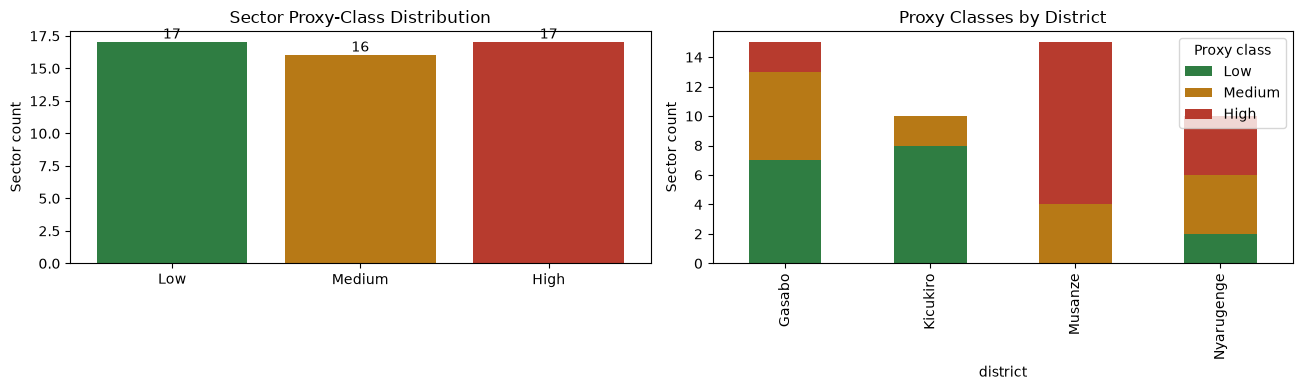

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(sector_class_counts.index, sector_class_counts.values, color=['#2f7d42', '#b77916', '#b73b2e'])
axes[0].set_title('Sector Proxy-Class Distribution')
axes[0].set_ylabel('Sector count')
for i, value in enumerate(sector_class_counts.values):
    axes[0].text(i, value + 0.3, str(value), ha='center')

district_class_counts.plot(kind='bar', stacked=True, ax=axes[1], color=['#2f7d42', '#b77916', '#b73b2e'])
axes[1].set_title('Proxy Classes by District')
axes[1].set_ylabel('Sector count')
axes[1].legend(title='Proxy class')
plt.tight_layout()
plt.show()

## 3. Tune, calibrate, and evaluate the models

The outer loop holds out one complete district for an honest geographic test. Inside each outer training fold, candidate hyperparameters are compared with another leave-one-district-out loop. Probabilities are averaged to one row per sector before temperature scaling is fitted. Calibration is deployed only when nested out-of-district log loss improves; otherwise the raw probabilities are retained.


In [5]:
models = workflow.make_models()
all_oof, all_folds, all_performance, all_importance, all_reports, all_tuning = [], [], [], [], [], []
fitted_models = {}

for model_name, model in models.items():
    print(f'Evaluating and tuning {model_name} with nested leave-one-district-out validation...')
    oof, fold_metrics, overall = workflow.evaluate_model(model_name, model, data, selected_features)
    fitted_full, best_parameters, candidate_temperature, tuning = workflow.fit_tuned_calibrated_model(
        model_name, model, data, selected_features
    )
    calibration_selected = bool(overall.iloc[0]['calibration_selected'])
    applied_temperature = candidate_temperature if calibration_selected else 1.0
    tuning.insert(0, 'model', model_name)
    tuning.insert(1, 'training_scope', 'all_sectors')
    tuning['selected'] = tuning['parameters_json'].eq(json.dumps(best_parameters, sort_keys=True))
    importance = workflow.feature_importance(model_name, fitted_full, selected_features)
    report = pd.DataFrame(
        classification_report(
            oof['proxy_class'],
            oof['predicted_proxy_class'],
            labels=workflow.CLASS_ORDER,
            output_dict=True,
            zero_division=0,
        )
    ).transpose().reset_index(names='metric_or_class')
    report.insert(0, 'model', model_name)

    all_oof.append(oof)
    all_folds.append(fold_metrics)
    all_performance.append(overall)
    all_importance.append(importance)
    all_reports.append(report)
    all_tuning.append(tuning)
    fitted_models[model_name] = {
        'model': fitted_full,
        'best_parameters': best_parameters,
        'calibration_selected': calibration_selected,
        'calibration_candidate_temperature': candidate_temperature,
        'calibration_temperature': applied_temperature,
    }

oof_predictions = pd.concat(all_oof, ignore_index=True)
district_fold_performance = pd.concat(all_folds, ignore_index=True)
model_performance = pd.concat(all_performance, ignore_index=True)
feature_importance = pd.concat(all_importance, ignore_index=True)
classification_reports = pd.concat(all_reports, ignore_index=True)
hyperparameter_tuning = pd.concat(all_tuning, ignore_index=True)
display(model_performance)


Evaluating and tuning random_forest with nested leave-one-district-out validation...


/Users/kellia.umuhire/Documents/capstone/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/Users/kellia.umuhire/Documents/capstone/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Evaluating and tuning catboost with nested leave-one-district-out validation...


/Users/kellia.umuhire/Documents/capstone/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/Users/kellia.umuhire/Documents/capstone/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


,model,held_out_district,test_row_count,accuracy,balanced_accuracy,macro_f1,macro_precision,macro_recall,log_loss,multiclass_brier_score,...,candidate_calibrated_accuracy,candidate_calibrated_balanced_accuracy,candidate_calibrated_macro_f1,candidate_calibrated_macro_precision,candidate_calibrated_macro_recall,candidate_calibrated_log_loss,candidate_calibrated_multiclass_brier_score,candidate_calibrated_mean_confidence,candidate_calibrated_confidence_accuracy_gap,calibration_selected
0,random_forest,all_oof,50,0.66,0.655637,0.648525,0.655844,0.655637,0.891860,0.518223,...,0.66,0.655637,0.648525,0.655844,0.655637,0.971213,0.575421,0.484056,-0.175944,False
1,catboost,all_oof,50,0.44,0.438725,0.363647,0.626068,0.438725,1.012974,0.604506,...,0.44,0.438725,0.363647,0.626068,0.438725,1.053282,0.638292,0.422238,-0.017762,False


,model,accuracy,macro_f1,mean_confidence,confidence_accuracy_gap,log_loss,raw_mean_confidence,raw_log_loss,candidate_calibrated_mean_confidence,candidate_calibrated_log_loss,calibration_selected
0,random_forest,0.66,0.648525,0.600366,-0.059634,0.891860,0.600366,0.891860,0.484056,0.971213,False
1,catboost,0.44,0.363647,0.539962,0.099962,1.012974,0.539962,1.012974,0.422238,1.053282,False


,model,held_out_district,test_row_count,accuracy,balanced_accuracy,macro_f1,macro_precision,macro_recall,log_loss,multiclass_brier_score,...,candidate_calibrated_accuracy,candidate_calibrated_balanced_accuracy,candidate_calibrated_macro_f1,candidate_calibrated_macro_precision,candidate_calibrated_macro_recall,candidate_calibrated_log_loss,candidate_calibrated_multiclass_brier_score,candidate_calibrated_mean_confidence,candidate_calibrated_confidence_accuracy_gap,calibration_selected
4,catboost,Gasabo,15,0.666667,0.500000,0.456328,0.433333,0.500000,0.714535,0.414549,...,0.666667,0.500000,0.456328,0.433333,0.500000,0.978411,0.585571,0.393055,-0.273612,False
5,catboost,Kicukiro,10,0.600000,0.375000,0.250000,0.250000,0.250000,0.878042,0.551399,...,0.600000,0.375000,0.250000,0.250000,0.250000,0.910239,0.560029,0.480125,-0.119875,False
6,catboost,Musanze,15,0.066667,0.045455,0.055556,0.333333,0.030303,1.279505,0.791252,...,0.066667,0.045455,0.055556,0.333333,0.030303,1.211326,0.743956,0.392757,0.326090,False
7,catboost,Nyarugenge,10,0.500000,0.583333,0.412698,0.333333,0.583333,1.195767,0.662431,...,0.500000,0.583333,0.412698,0.333333,0.583333,1.071568,0.637142,0.452345,-0.047655,False
0,random_forest,Gasabo,15,0.666667,0.500000,0.459259,0.462121,0.500000,0.749258,0.446167,...,0.666667,0.500000,0.459259,0.462121,0.500000,0.974703,0.583532,0.398642,-0.268024,False
1,random_forest,Kicukiro,10,0.600000,0.375000,0.250000,0.250000,0.250000,0.881997,0.552370,...,0.600000,0.375000,0.250000,0.250000,0.250000,0.882744,0.549370,0.539642,-0.060358,False
2,random_forest,Musanze,15,0.733333,0.500000,0.293333,0.261905,0.333333,0.880965,0.495659,...,0.733333,0.500000,0.293333,0.261905,0.333333,0.952728,0.559303,0.441927,-0.291406,False
3,random_forest,Nyarugenge,10,0.600000,0.666667,0.555556,0.500000,0.666667,1.131970,0.626008,...,0.600000,0.666667,0.555556,0.500000,0.666667,1.082172,0.613485,0.619782,0.019782,False


,model,training_scope,candidate_index,parameters_json,mean_inner_macro_f1,std_inner_macro_f1,selected
0,random_forest,all_sectors,3,"{""model__max_depth"": 6, ""model__max_features"":...",0.392778,0.125581,True
4,catboost,all_sectors,4,"{""model__depth"": 4, ""model__iterations"": 200, ...",0.297863,0.132299,True


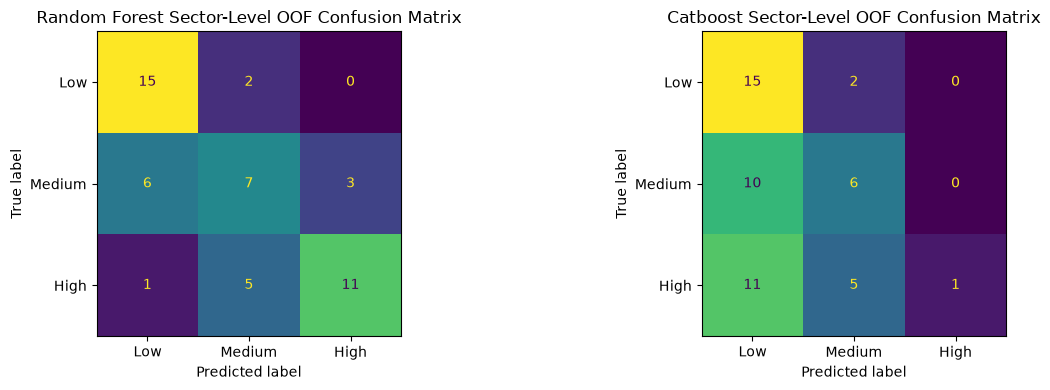

In [6]:
calibration_columns = [
    'model', 'accuracy', 'macro_f1', 'mean_confidence', 'confidence_accuracy_gap', 'log_loss',
    'raw_mean_confidence', 'raw_log_loss', 'candidate_calibrated_mean_confidence',
    'candidate_calibrated_log_loss', 'calibration_selected',
]
display(model_performance[calibration_columns])
display(district_fold_performance.sort_values(['model', 'held_out_district']))
display(hyperparameter_tuning.loc[hyperparameter_tuning['selected']])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for axis, model_name in zip(axes, ['random_forest', 'catboost']):
    subset = oof_predictions[oof_predictions['model'].eq(model_name)]
    matrix = confusion_matrix(subset['proxy_class'], subset['predicted_proxy_class'], labels=workflow.CLASS_ORDER)
    ConfusionMatrixDisplay(matrix, display_labels=workflow.CLASS_ORDER).plot(ax=axis, colorbar=False)
    axis.set_title(model_name.replace('_', ' ').title() + ' Sector-Level OOF Confusion Matrix')
plt.tight_layout()
plt.show()


## 4. Feature importance and transparent hybrid sector assessments

Importance is descriptive, not causal. Random Forest is the primary model because it has the strongest district-held-out performance. Its score is `P(High) + 0.5 × P(Medium)`. The final transparent hybrid index combines 60% of that out-of-fold model score with 40% of the census indicator score. The weights are explicit decision assumptions, not learned parameters, and the components are related because the model target came from the indicator class.


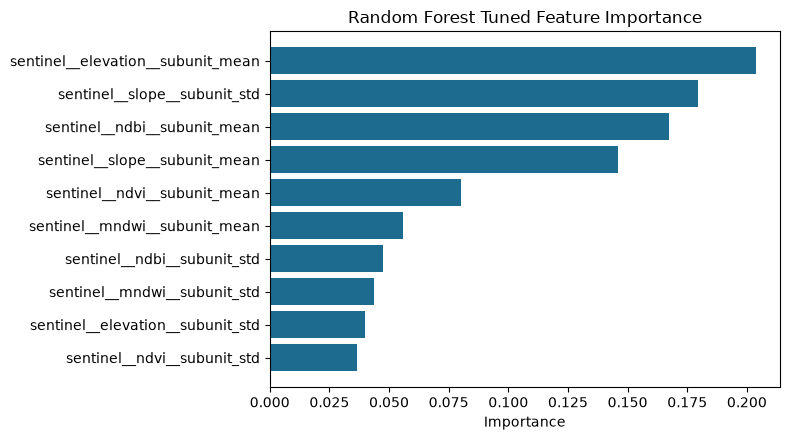

,model,feature,importance
0,random_forest,sentinel__elevation__subunit_mean,0.203692
1,random_forest,sentinel__slope__subunit_std,0.179461
2,random_forest,sentinel__ndbi__subunit_mean,0.167364
3,random_forest,sentinel__slope__subunit_mean,0.145840
4,random_forest,sentinel__ndvi__subunit_mean,0.080157
5,random_forest,sentinel__mndwi__subunit_mean,0.055969
6,random_forest,sentinel__ndbi__subunit_std,0.047499
7,random_forest,sentinel__mndwi__subunit_std,0.043527
8,random_forest,sentinel__elevation__subunit_std,0.039860
9,random_forest,sentinel__ndvi__subunit_std,0.036632


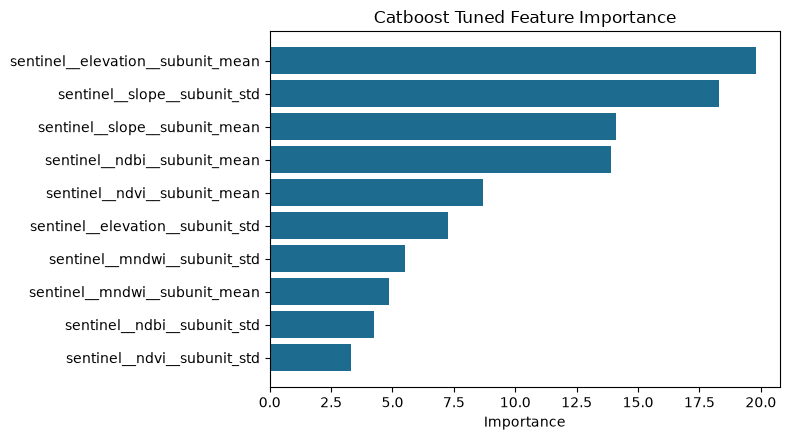

,model,feature,importance
10,catboost,sentinel__elevation__subunit_mean,19.791743
11,catboost,sentinel__slope__subunit_std,18.306696
12,catboost,sentinel__slope__subunit_mean,14.119462
13,catboost,sentinel__ndbi__subunit_mean,13.911733
14,catboost,sentinel__ndvi__subunit_mean,8.672323
15,catboost,sentinel__elevation__subunit_std,7.259189
16,catboost,sentinel__mndwi__subunit_std,5.524856
17,catboost,sentinel__mndwi__subunit_mean,4.855831
18,catboost,sentinel__ndbi__subunit_std,4.256029
19,catboost,sentinel__ndvi__subunit_std,3.302139


,sector_id,sector_name,district,proxy_class,proxy_score,proxy_rank,primary_model,probability_low,probability_medium,probability_high,...,hybrid_model_weight,hybrid_indicator_weight,hybrid_model_contribution,hybrid_indicator_contribution,hybrid_vulnerability_score,hybrid_vulnerability_class,hybrid_priority_rank,hybrid_class_threshold_method,hybrid_class_low_upper_score,hybrid_class_medium_upper_score
34,RWA.1.4.4_1,Gashaki,Musanze,High,0.517564,3,random_forest,0.197359,0.235197,0.567443,...,0.6,0.4,0.411025,0.207026,0.618051,High,1,study_area_hybrid_score_tertiles,0.266106,0.445148
28,RWA.1.4.13_1,Remera,Musanze,High,0.523125,2,random_forest,0.243455,0.214738,0.541806,...,0.6,0.4,0.389505,0.209250,0.598756,High,2,study_area_hybrid_score_tertiles,0.266106,0.445148
29,RWA.1.4.14_1,Rwaza,Musanze,High,0.509530,4,random_forest,0.281206,0.182572,0.536222,...,0.6,0.4,0.376505,0.203812,0.580317,High,3,study_area_hybrid_score_tertiles,0.266106,0.445148
37,RWA.1.4.7_1,Kinigi,Musanze,High,0.441454,9,random_forest,0.223814,0.211052,0.565134,...,0.6,0.4,0.402396,0.176582,0.578978,High,4,study_area_hybrid_score_tertiles,0.266106,0.445148
30,RWA.1.4.15_1,Shingiro,Musanze,High,0.462571,8,random_forest,0.288733,0.166872,0.544394,...,0.6,0.4,0.376698,0.185028,0.561726,High,5,study_area_hybrid_score_tertiles,0.266106,0.445148
33,RWA.1.4.3_1,Gacaca,Musanze,High,0.462987,7,random_forest,0.263872,0.219236,0.516892,...,0.6,0.4,0.375906,0.185195,0.561101,High,6,study_area_hybrid_score_tertiles,0.266106,0.445148
27,RWA.1.4.12_1,Nyange,Musanze,High,0.362825,15,random_forest,0.214960,0.217945,0.567096,...,0.6,0.4,0.405641,0.145130,0.550771,High,7,study_area_hybrid_score_tertiles,0.266106,0.445148
35,RWA.1.4.5_1,Gataraga,Musanze,High,0.383675,13,random_forest,0.242313,0.195663,0.562025,...,0.6,0.4,0.395913,0.153470,0.549384,High,8,study_area_hybrid_score_tertiles,0.266106,0.445148
26,RWA.1.4.11_1,Nkotsi,Musanze,High,0.388099,12,random_forest,0.269143,0.178852,0.552005,...,0.6,0.4,0.384859,0.155240,0.540098,High,9,study_area_hybrid_score_tertiles,0.266106,0.445148
39,RWA.1.4.9_1,Muko,Musanze,High,0.381857,14,random_forest,0.298216,0.180916,0.520868,...,0.6,0.4,0.366795,0.152743,0.519538,High,10,study_area_hybrid_score_tertiles,0.266106,0.445148


,mean_absolute_rank_change,maximum_absolute_rank_change,top_10_sector_count
scenario,,,
indicator_model_equal_50_50,1.00,4,10
model_emphasis_70_indicator_30,0.92,5,10
recommended_model_60_indicator_40,0.00,0,10


In [7]:
for model_name in ['random_forest', 'catboost']:
    subset = feature_importance[feature_importance['model'].eq(model_name)].sort_values('importance', ascending=True)
    plt.figure(figsize=(8, 4.5))
    plt.barh(subset['feature'], subset['importance'], color='#1d6b8f')
    plt.title(model_name.replace('_', ' ').title() + ' Tuned Feature Importance')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()
    display(subset.sort_values('importance', ascending=False))

probability_columns = [f'probability_{label.lower()}' for label in workflow.CLASS_ORDER]
assessment_columns = [
    'sector_id', 'sector_name', 'district', 'proxy_class', 'proxy_score', 'proxy_rank', *probability_columns
]
sector_assessments = oof_predictions.loc[
    oof_predictions['model'].eq(workflow.PRIMARY_ASSESSMENT_MODEL), assessment_columns
].copy()
if sector_assessments['sector_id'].duplicated().any():
    raise ValueError('Primary-model assessments must contain one row per sector.')
sector_assessments.insert(6, 'primary_model', workflow.PRIMARY_ASSESSMENT_MODEL)
sector_assessments['model_predicted_class'] = (
    sector_assessments[probability_columns].idxmax(axis=1).str.replace('probability_', '').str.title()
)
sector_assessments['model_probability'] = sector_assessments[probability_columns].max(axis=1)
sector_assessments['model_vulnerability_score'] = (
    sector_assessments['probability_high'] + 0.5 * sector_assessments['probability_medium']
)
sector_assessments['model_priority_rank'] = (
    sector_assessments['model_vulnerability_score'].rank(method='first', ascending=False).astype(int)
)
sector_assessments['model_agrees_with_proxy_label'] = sector_assessments['model_predicted_class'].eq(
    sector_assessments['proxy_class']
)
sector_assessments = workflow.add_hybrid_assessment_fields(sector_assessments)
hybrid_sensitivity = workflow.hybrid_sensitivity_analysis(sector_assessments)
display(sector_assessments.sort_values('hybrid_priority_rank'))
display(hybrid_sensitivity.groupby('scenario').agg(
    mean_absolute_rank_change=('rank_change_from_60_40', lambda values: values.abs().mean()),
    maximum_absolute_rank_change=('rank_change_from_60_40', lambda values: values.abs().max()),
    top_10_sector_count=('in_top_10', 'sum'),
))


## 5. Save reproducible outputs

This writes the notebook-run tuning results, calibration diagnostics, sector-level out-of-fold predictions, feature importance, hybrid assessments, weight sensitivity results, and fitted model bundles to the project locations used by the command-line pipeline.


In [8]:
workflow.write_csv(training_view, OUTPUT_DIR / 'training_dataset.csv')
workflow.write_csv(feature_summary, OUTPUT_DIR / 'feature_summary.csv')
workflow.write_csv(district_class_counts.reset_index(), OUTPUT_DIR / 'district_class_distribution.csv')
workflow.write_csv(model_performance, OUTPUT_DIR / 'model_performance.csv')
workflow.write_csv(district_fold_performance, OUTPUT_DIR / 'district_fold_performance.csv')
workflow.write_csv(oof_predictions, OUTPUT_DIR / 'out_of_fold_predictions.csv')
workflow.write_csv(feature_importance, OUTPUT_DIR / 'feature_importance.csv')
workflow.write_csv(hyperparameter_tuning, OUTPUT_DIR / 'hyperparameter_tuning.csv')
workflow.write_csv(classification_reports, OUTPUT_DIR / 'classification_report.csv')
workflow.write_csv(sector_assessments.sort_values('hybrid_priority_rank'), OUTPUT_DIR / 'sector_model_assessments.csv')
workflow.write_csv(hybrid_sensitivity, OUTPUT_DIR / 'hybrid_weight_sensitivity.csv')

for model_name, fitted_bundle in fitted_models.items():
    joblib.dump(
        {
            **fitted_bundle,
            'feature_columns': selected_features,
            'calibration_method': (
                'sector_level_temperature_scaling'
                if fitted_bundle['calibration_selected']
                else 'identity_calibration'
            ),
            'target': 'proxy_class',
            'training_unit': training_unit,
            'training_row_count': len(data),
            'independent_sector_count': int(data['sector_id'].nunique()),
            'evaluation': 'nested_leave_one_district_out',
            'caveat': 'Proxy-label pilot. Do not interpret as validated Ubudehe prediction.',
        },
        MODEL_DIR / f'sector_proxy_{model_name}.joblib',
    )

print(f'Saved outputs to: {OUTPUT_DIR}')
print(f'Saved tuned models to: {MODEL_DIR}')


Saved outputs to: /Users/kellia.umuhire/Documents/capstone/data/model_outputs
Saved tuned models to: /Users/kellia.umuhire/Documents/capstone/models


## Interpretation guardrails

- The x10 table has more training rows, but still only 50 independent sector labels.
- All ten sector subunits inherit the same sector-level proxy label.
- The target is a census-informed proxy, not an official Ubudehe category.
- The final hybrid score is `60% Random Forest + 40% census indicator`; these are documented decision weights, not weights learned from independent outcomes.
- The two hybrid components are related because the Random Forest learned an indicator-derived target, so the index is an ML-assisted prioritisation tool rather than two independent estimates.
- Model performance estimates have high uncertainty and should be treated as pilot results.
- More independent labels, or a finer label geography, are required before operational deployment.
- Calibration is rejected when nested held-out log loss does not improve; confidence is never increased only for appearance.
